In [ ]:
from data import caponSpectrumTruth, capon3, capon4
import numpy as np
import matplotlib.pyplot as plt

# data = np.array(caponSpectrumTruth).reshape((32,32))[::2]
# plt.imshow(data, cmap='hot', interpolation='nearest')
# plt.colorbar(label='Intensity')
# plt.title('Heatmap using Matplotlib')
# plt.xlabel('Azimuth')
# plt.ylabel('Elevation')
# plt.show()

# re = np.array(capon3).reshape((32,32)).transpose()[::2]

# #data3 = np.rot90(data3, 1)
# plt.imshow(re, cmap='hot', interpolation='nearest')
# plt.colorbar(label='Intensity')
# plt.title('Heatmap using Matplotlib')
# plt.xlabel('Azimuth')
# plt.ylabel('Elevation')
# plt.show()




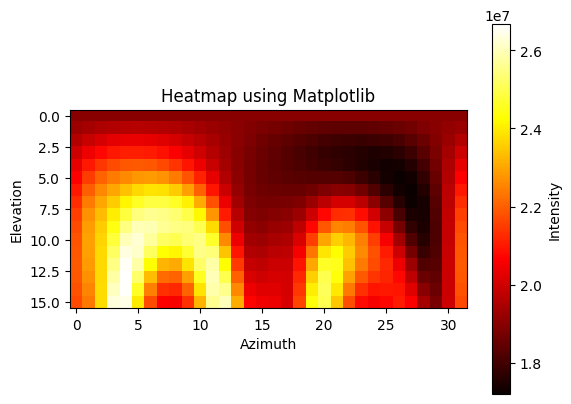

In [8]:
data = np.array(capon4).reshape((10,32,16))
data = np.rot90(m=data, axes=(2,1))
plt.imshow(data[5], cmap='hot', interpolation='nearest')
plt.colorbar(label='Intensity')
plt.title('Heatmap using Matplotlib')
plt.xlabel('Azimuth')
plt.ylabel('Elevation')
plt.show()

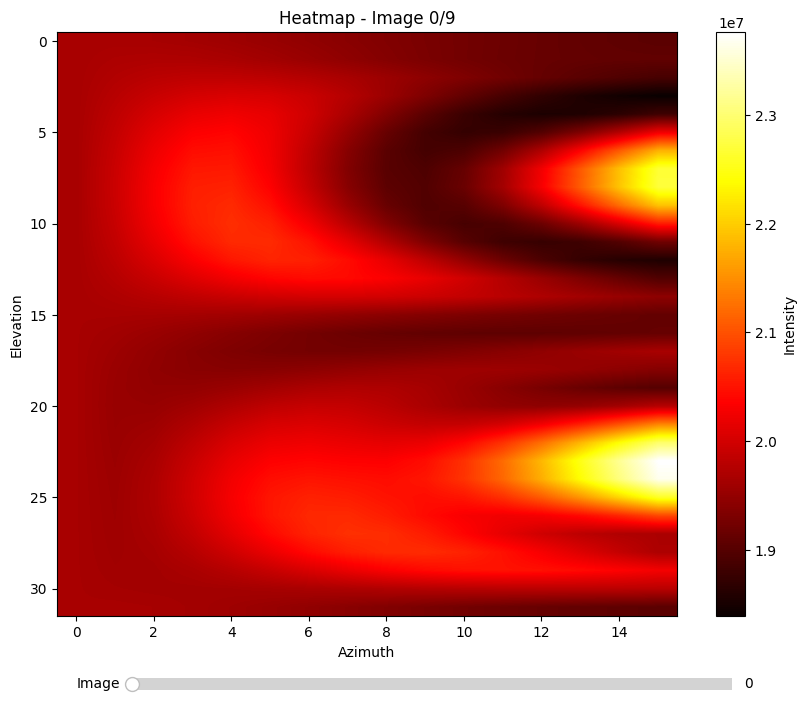

In [ ]:
import struct
import numpy as np

testConfig = {
    'numRangeBins':64,
    'numTxAntennas':2,
    'numRxAntennas':3,
    'numChirpsPerFrame':32,
}
split_complex = False

with open("adc_data_0001_CtestAdc6Ant_demo_RadarCube.bin", "rb") as f:
    num_samples = testConfig['numRangeBins'] * testConfig['numRxAntennas'] * testConfig['numChirpsPerFrame']
    bytes_to_read = num_samples * 8  # 4 bytes par échantillon complexe
    
    # Lecture des données binaires
    data = f.read(bytes_to_read)
    
    # Conversion en tableau numpy de int16
    # '<i2' signifie little-endian int16
    radarCubeRef = np.frombuffer(data, dtype='<i2')
    
    if split_complex : 
        # Reshape en tableau complexe (partie réelle et imaginaire)
        radarCubeRef = radarCubeRef.reshape(-1, 2)  # Chaque ligne = [real, imag]
        
        # Optionnel : convertir en type complexe numpy
        radarCubeRef_complex = radarCubeRef[:, 0] + 1j * radarCubeRef[:, 1]
        
        # Ou reshape selon les dimensions du radar cube
        radarCubeRef_output = radarCubeRef_complex.reshape(
            testConfig['numRangeBins'],
            testConfig['numTxAntennas'],
            testConfig['numRxAntennas'],
            testConfig['numChirpsPerFrame'],
        )
    else:
        # Ou reshape selon les dimensions du radar cube
        radarCubeRef_output = radarCubeRef.reshape(
            testConfig['numRangeBins'],
            testConfig['numTxAntennas'],
            testConfig['numRxAntennas'],
            testConfig['numChirpsPerFrame'],
            2
        )

In [3]:
radarCubeRef_output[0,0,0]

array([[  0, -46],
       [  6,  26],
       [ -3,  -1],
       [  1,   1],
       [ 14,  -8],
       [-31,  15],
       [ 36, -13],
       [-30,   7],
       [ 22,  -4],
       [ -9,   4],
       [  5,  -5],
       [-13, -10],
       [ 22,  44],
       [-21, -69],
       [  6,  55],
       [  8, -29],
       [  2,  22],
       [-15, -13],
       [ 19,  -2],
       [-29,   3],
       [ 29,  -3],
       [-10,  18],
       [ -1, -15],
       [ -3,   0],
       [  7,  -9],
       [ -9,  20],
       [  7,  -7],
       [ -6,  -4],
       [ 14,  -8],
       [-13,  24],
       [ -6, -20],
       [ 23,  14]], dtype=int16)

In [4]:
radarCubeRef_output.shape

(64, 2, 3, 32, 2)

In [5]:
radar_range0_caponinput = np.transpose(radarCubeRef_output,axes=(0, 3, 1, 2, 4))
data_reordered = radar_range0_caponinput.reshape(64, 32, 6, 2)
data_reordered[0].shape

(32, 6, 2)

In [6]:
output_filename = "caponData2D_test2.bin"
radarCubeRef_to_write = data_reordered[2].flatten().astype('<i4')

# Écriture dans le fichier binaire
with open(output_filename, "wb") as f:
    f.write(radarCubeRef_to_write.tobytes())

print(f"Fichier '{output_filename}' créé avec succès")
print(f"Taille écrite: {radarCubeRef_to_write.nbytes} bytes")

Fichier 'caponData2D_test2.bin' créé avec succès
Taille écrite: 1536 bytes
